# Original Code (adapted for mac mps)

In [1]:
# set constants for sizes of model output 
from tnscui_utils.TNSCUI_preprocess import TNSCUI_preprocess
import csv
import os
import traceback
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from typing import Dict, List, Optional, Tuple

import numpy as np
import torch
import ttach as tta
from PIL import Image
from skimage.measure import label as sklabel
from skimage.measure import regionprops
from skimage.transform import resize
import segmentation_models_pytorch_4TorchLessThan120 as smp

# LOAD DATA CONFIGS 
PROJECT_ROOT = Path(
    "/Users/JanayeCheong/Documents/radiomics_segmentation_models/"
    "TNSCUI2020-Seg-Rank1st"
)

IMG_DIR = PROJECT_ROOT / "train_thyroidXL" / "raw_images"
MASK_DIR = PROJECT_ROOT / "train_thyroidXL" / "masks"

WEIGHT_C1 = (
    PROJECT_ROOT
    / "weigh_and_id"
    / "TNSCUI"
    / "fold1_stage1_trained_on_size_256.pkl"
)

OUTPUT_DIR = PROJECT_ROOT / "probability_outputs_pass_one"

PREDICTION_DIR = OUTPUT_DIR / "predicted_masks"
OVERLAY_DIR = OUTPUT_DIR / "overlays"


PROBABILITY_DIR = OUTPUT_DIR / "probability_maps"
PROBABILITY_NUMPY_DIR = OUTPUT_DIR / "probability_arrays"
PROBABILITY_OVERLAY_DIR = OUTPUT_DIR / "probability_overlays"

METRICS_CSV = OUTPUT_DIR / "stage1_probability_metrics.csv"

C1_SIZE = 256

C1_TTA = True

ORIMG = False
C1_THRESHOLD = 0.5

PROBABILITY_ANALYSIS_THRESHOLDS = [
    0.05,
    0.10,
    0.20,
    0.30,
    0.40,
]

SAVE_OVERLAYS = True
CONTINUE_ON_ERROR = True
MAX_IMAGES = None  # e.g. 10 for a quick test; None runs the full dataset

SUPPORTED_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff",
}

In [2]:
def thyroidxl_preprocess(
    image_path: Path,
    outputsize: C1_SIZE, # C1_SIZE variable should be set to 256 x 256 
    # equivalent to TNSCUI_preprocess and removal of 1) black edges 2) irrelevant areas 
    # double check whether functions similarly ot the MATLAB process 
    remove_black_edges: bool = True,
    
    # function works by finding the first valid row pixels and column pixels, then retaining image on a foreground
):
    """
    ThyroidXL dataset safe replacement for TNSCUI_preprocess.

    Returns
    -------
    processed_tensor:
        Float tensor with shape [output_size, output_size].

    cut_shape:
        Shape of the retained image before resizing (to typical image tensor size).

    original_shape:
        Original image shape: (height, width).

    location:
        Coordinates of the retained image in the original image (the start and end of valid rows and columns):
        [row_start, row_end, col_start, col_end].
    """

    # Force the image into one grayscale channel.
    with Image.open(image_path) as image:
        image = image.convert("L") # convert grayscale channel?? 
        image_array = np.asarray(image, dtype=np.float32) # createa a numpy array of the image based on pixels and grayscale

    original_shape = image_array.shape

    if image_array.ndim != 2:
        raise ValueError(
            f"Expected a 2-D grayscale image, got {image_array.shape} "
            f"for {image_path.name}"
        ) # CHECK THAT THE IMAGE IS 2-DIMENSIONAL 

    if remove_black_edges: ## TODO: FIND BETTER WAY TO REMOVE BLACK EDGES
        # Detect rows and columns that contain meaningful ultrasound content.
        #
        # A small threshold is used instead of requiring pixels to be exactly
        # zero because ultrasound borders may contain compression noise.
        foreground_threshold = 5.0 # adjust for sensitivity to the saturation on the gray scale 

        valid_rows = np.where(
            np.mean(image_array, axis=1) > foreground_threshold # calculate image areas where the average of ROW pixels is greater than threshold 
        )[0]

        valid_cols = np.where(
            np.mean(image_array, axis=0) > foreground_threshold # calculate image areas where the average of COLUMN pixels is greater than threshold
        )[0]

        if len(valid_rows) > 0 and len(valid_cols) > 0: # find the foreground of the image based on the first valid row and the last + 1 valid row
            row_start = int(valid_rows[0])
            row_end = int(valid_rows[-1]) + 1

            col_start = int(valid_cols[0]) # do the same for the columns 
            col_end = int(valid_cols[-1]) + 1
        else:
            # Fall back to the complete image if no foreground is detected.
            row_start = 0
            row_end = original_shape[0]
            col_start = 0
            col_end = original_shape[1]

    else:
        row_start = 0
        row_end = original_shape[0] # x value of original shape (row end / max)
        col_start = 0
        col_end = original_shape[1] # y value of original shape (column end)

    cropped_image = image_array[
        row_start:row_end,
        col_start:col_end,
        
    ] # array is now cropped without black edges 

    if cropped_image.size == 0:
        raise ValueError(
            f"Black-edge removal produced an empty image for "
            f"{image_path.name}"
        )

    cut_shape = cropped_image.shape
    location = [row_start, row_end, col_start, col_end]

    # Resize to the stage-1 output_size (256 x 256) for the neural network.
    processed_array = resize(
        cropped_image,
        (outputsize, outputsize),
        order=3,
        preserve_range=True,
        anti_aliasing=True,
    ).astype(np.float32)

    # Match the common neural-network image range.
    if processed_array.max() > 1.0:
        processed_array /= 255.0

    processed_tensor = torch.from_numpy(processed_array) # convert the image to a tensor (different from TNSCUI_preprocess where originally converted to tensor)

    return processed_tensor, cut_shape, original_shape, location

In [3]:

# Metrics SAME AS original TNSCUI Model 
def get_iou(prediction: np.ndarray, ground_truth: np.ndarray) -> float:
    """Calculate intersection over union for two binary arrays --> corresponds to ."""
    prediction = prediction.astype(bool)
    ground_truth = ground_truth.astype(bool)

    intersection = np.logical_and(prediction, ground_truth).sum()
    union = np.logical_or(prediction, ground_truth).sum()

    if union == 0:
        return 1.0

    return float(intersection / union)


def get_dsc(prediction: np.ndarray, ground_truth: np.ndarray) -> float:
    """Calculate Dice similarity coefficient for two binary arrays."""
    prediction = prediction.astype(bool)
    ground_truth = ground_truth.astype(bool)

    intersection = np.logical_and(prediction, ground_truth).sum()
    denominator = prediction.sum() + ground_truth.sum()

    if denominator == 0:
        return 1.0

    return float((2.0 * intersection) / denominator)


def largest_connected_component(binary_mask: np.ndarray) -> np.ndarray:
    """Retain only the largest foreground connected component from binary threshold."""
    binary_mask = binary_mask.astype(bool)

    if binary_mask.sum() == 0:
        return binary_mask.astype(np.float32)

    labeled_img, num_components = sklabel(
        binary_mask,
        connectivity=1,
        background=0,
        return_num=True,
    )

    if num_components == 1:
        return binary_mask.astype(np.float32)

    component_sizes = [
        np.sum(labeled_img == component_label)
        for component_label in range(1, num_components + 1)
    ]

    largest_label = int(np.argmax(component_sizes)) + 1
    return (labeled_img == largest_label).astype(np.float32)


def calculate_stage2_roi(
    stage1_mask: np.ndarray,
    c1_size: int = 256,
) -> Tuple[int, int, int, int]:
    """
    Calculate the expanded square ROI used as input to Stage 2.

    Returns
    -------
    row_min, row_max, col_min, col_max
    """
    if stage1_mask.sum() == 0:
        min_row, min_col, max_row, max_col = 0, 0, c1_size, c1_size
    else:
        region = regionprops(stage1_mask.astype(np.uint8))[0]
        min_row, min_col, max_row, max_col = region.bbox

    row_center = (max_row + min_row) // 2
    col_center = (max_col + min_col) // 2
    max_length = max(max_row - min_row, max_col - min_col)

    large_roi_threshold = int((c1_size / 256) * 80)
    large_roi_margin = int((c1_size / 256) * 19)
    small_roi_margin = int((c1_size / 256) * 31)

    if max_length > large_roi_threshold:
        expansion = large_roi_margin + max_length // 2
    else:
        expansion = small_roi_margin + max_length // 2

    row_min = max(0, row_center - expansion)
    row_max = min(c1_size, row_center + expansion)
    col_min = max(0, col_center - expansion)
    col_max = min(c1_size, col_center + expansion)

    # IN case the crop is empty    
    if row_max <= row_min or col_max <= col_min:
        return 0, c1_size, 0, c1_size

    return row_min, row_max, col_min, col_max


# save files in order 

def discover_images(image_dir: Path) -> List[Path]:
    """Return every supported image file recursively, in stable order."""
    files = [
        path
        for path in image_dir.rglob("*")
        if path.is_file() and path.suffix.lower() in SUPPORTED_EXTENSIONS
    ]
    return sorted(files, key=lambda path: str(path).lower())


def build_mask_index(mask_dir: Path) -> Dict[str, Path]:
    """
    Index masks by filename stem, case-insensitively.

    The image and mask may have different filename extensions, but their stems
    must match
    """
    index: Dict[str, Path] = {}

    for path in discover_images(mask_dir):
        key = path.stem.lower()

        if key in index:
            raise ValueError(
                f"Duplicate mask stem '{path.stem}' found:\n"
                f"  {index[key]}\n"
                f"  {path}"
            )

        index[key] = path

    return index


def load_binary_mask(mask_path: Path, expected_shape: Tuple[int, int]) -> np.ndarray:
    """Read a mask as grayscale and convert it to a binary NumPy array."""
    mask = Image.open(mask_path).convert("L")
    mask_array = np.asarray(mask, dtype=np.float32)

    if mask_array.shape != expected_shape:
        raise ValueError(
            f"Ground-truth mask shape {mask_array.shape} does not match "
            f"original image shape {expected_shape} for {mask_path.name}."
        )

    return (mask_array > 0).astype(np.float32)


def save_binary_mask(mask: np.ndarray, output_path: Path) -> None:
    """Save a binary mask as an 8-bit PNG."""
    output_path.parent.mkdir(parents=True, exist_ok=True)
    mask_uint8 = (mask.astype(bool).astype(np.uint8) * 255)
    Image.fromarray(mask_uint8, mode="L").save(output_path)


def mask_bbox(mask: np.ndarray) -> Optional[Tuple[int, int, int, int]]:
    """
    Return the axis-aligned bounding box of foreground pixels.

    Returns (row_min, col_min, row_max, col_max) in regionprops format,
    where row_max/col_max are exclusive upper bounds.
    """
    if mask.astype(bool).sum() == 0:
        return None

    region = regionprops(mask.astype(np.uint8))[0]
    return region.bbox


def draw_bbox_on_rgb(
    rgb: np.ndarray,
    bbox: Tuple[int, int, int, int],
    color: Tuple[float, float, float] = (0.0, 0.85, 1.0),
    thickness: int = 2,
) -> None:
    """Draw a rectangle on an RGB float image in [0, 1]."""
    row_min, col_min, row_max, col_max = bbox
    height, width = rgb.shape[:2]

    row_min = max(0, int(row_min))
    col_min = max(0, int(col_min))
    row_max = min(height, int(row_max))
    col_max = min(width, int(col_max))

    if row_max <= row_min or col_max <= col_min:
        return

    for offset in range(thickness):
        top = row_min + offset
        bottom = row_max - 1 - offset
        left = col_min + offset
        right = col_max - 1 - offset

        if top < height:
            rgb[top, col_min:col_max, :] = color
        if bottom >= 0:
            rgb[bottom, col_min:col_max, :] = color
        if left < width:
            rgb[row_min:row_max, left, :] = color
        if right >= 0:
            rgb[row_min:row_max, right, :] = color


def save_overlay(
    image_path: Path,
    prediction: np.ndarray,
    ground_truth: Optional[np.ndarray],
    output_path: Path,
    prediction_bbox: Optional[Tuple[int, int, int, int]] = None,
    bbox_color: Tuple[float, float, float] = (0.0, 0.85, 1.0),
    bbox_thickness: int = 2,
) -> None:
    """
    Save an RGB overlay:
    - red: the prediction
    - green: the ground truth (from given mask)
    - yellow: overlap
    - cyan box: optional bounding box showing where the prediction lands
    """
    original = Image.open(image_path).convert("L")
    base = np.asarray(original, dtype=np.float32)

    if base.max() > base.min():
        base = (base - base.min()) / (base.max() - base.min())
    else:
        base = np.zeros_like(base)

    rgb = np.stack([base, base, base], axis=-1)
    prediction_bool = prediction.astype(bool)

    rgb[prediction_bool, 0] = 1.0
    rgb[prediction_bool, 1] *= 0.35
    rgb[prediction_bool, 2] *= 0.35

    if ground_truth is not None:
        ground_truth_bool = ground_truth.astype(bool)
        rgb[ground_truth_bool, 1] = 1.0
        rgb[ground_truth_bool, 0] *= 0.35
        rgb[ground_truth_bool, 2] *= 0.35

        overlap = np.logical_and(prediction_bool, ground_truth_bool)
        rgb[overlap, 0] = 1.0
        rgb[overlap, 1] = 1.0
        rgb[overlap, 2] = 0.0

    if prediction_bbox is None:
        prediction_bbox = mask_bbox(prediction)

    if prediction_bbox is not None:
        draw_bbox_on_rgb(
            rgb,
            prediction_bbox,
            color=bbox_color,
            thickness=bbox_thickness,
        )

    output_path.parent.mkdir(parents=True, exist_ok=True)
    Image.fromarray((np.clip(rgb, 0, 1) * 255).astype(np.uint8), mode="RGB").save(
        output_path
    )


# ============================================================================
# Model loading and inference
# ============================================================================

def choose_device() -> torch.device:
    """Prefer Apple MPS, then CUDA, then CPU."""
    if torch.backends.mps.is_available():
        return torch.device("mps")

    if torch.cuda.is_available():
        return torch.device("cuda")

    return torch.device("cpu")


def extract_state_dict(checkpoint):
    """
    Support either a direct state_dict or a checkpoint dictionary containing
    a state_dict/model_state_dict field.
    """
    if not isinstance(checkpoint, dict):
        return checkpoint

    if "state_dict" in checkpoint:
        return checkpoint["state_dict"]

    if "model_state_dict" in checkpoint:
        return checkpoint["model_state_dict"]

    return checkpoint


def load_model(
    weight_path: Path,
    device: torch.device,
    transforms,
    use_tta: bool,
) -> torch.nn.Module:
    """Create a DeepLabV3+ model and load pretrained weights."""
    if not weight_path.exists():
        raise FileNotFoundError(f"Weight file not found: {weight_path}")

    model = smp.DeepLabV3Plus(
        encoder_name="efficientnet-b6",
        encoder_weights=None,
        in_channels=1,
        classes=1,
    )

    # CPU deserialization is typically the safest for old checkpoints.
    checkpoint = torch.load(weight_path, map_location="cpu")
    state_dict = extract_state_dict(checkpoint)

    try:
        model.load_state_dict(state_dict, strict=True)
    except RuntimeError as exc:
        print(
            f"Strict loading failed for {weight_path.name}; "
            "retrying with strict=False."
        )
        print(exc)
        incompatible = model.load_state_dict(state_dict, strict=False)
        print("Missing keys:", incompatible.missing_keys)
        print("Unexpected keys:", incompatible.unexpected_keys)

    model = model.to(device)
    model.eval()

    if use_tta:
        model = tta.SegmentationTTAWrapper(
            model,
            transforms,
            merge_mode="mean",
        )
        model.eval()

    return model


In [4]:
# TODO : IMPLEMENT THE TNSCUI_preprocess4reesemble from the TNSCUI_prerpcoess file that remakes the image with mask in original dimensions from the map

def restore_mask_to_original(
    mask_256: np.ndarray,
    cut_shape: Tuple[int, int],
    original_shape: Tuple[int, int],
    location: List[int],
) -> np.ndarray:
    """Map a 256x256 binary mask back to original image coordinates."""
    restored_cut_mask = resize(
        mask_256,
        tuple(int(v) for v in cut_shape),
        order=0,
        preserve_range=True,
        anti_aliasing=False,
    )
    restored_cut_mask = (restored_cut_mask > 0.5).astype(np.float32)

    original_shape = tuple(int(v) for v in original_shape)
    final_mask = np.zeros(original_shape, dtype=np.float32)

    row_start, row_end, col_start, col_end = [int(v) for v in location]
    target_shape = (row_end - row_start, col_end - col_start)

    if restored_cut_mask.shape != target_shape:
        restored_cut_mask = resize(
            restored_cut_mask,
            target_shape,
            order=0,
            preserve_range=True,
            anti_aliasing=False,
        )
        restored_cut_mask = (restored_cut_mask > 0.5).astype(np.float32)

    final_mask[row_start:row_end, col_start:col_end] = restored_cut_mask
    return (final_mask > 0.5).astype(np.float32)


def get_recall(prediction: np.ndarray, ground_truth: np.ndarray) -> float:
    """Recall = TP / (TP + FN) — how much of the true nodule Stage 1 captured."""
    prediction = prediction.astype(bool)
    ground_truth = ground_truth.astype(bool)

    true_positive = np.logical_and(prediction, ground_truth).sum()
    false_negative = np.logical_and(~prediction, ground_truth).sum()

    if true_positive + false_negative == 0:
        return 1.0

    return float(true_positive / (true_positive + false_negative))


def run_stage1_only(
    image_path: Path,
    model_cascade1: torch.nn.Module,
    device: torch.device,
):
    """
    Run Stage 1 only and PRESERVE its probability information.

    Returns
    -------
    stage1_probability_original:
        Continuous Stage-1 probability map restored to original
        image dimensions.

    stage1_probability_256:
        Continuous Stage-1 probability map at 256x256.

    stage1_binary_raw_256:
        Thresholded Stage-1 prediction BEFORE largest-connected-component
        filtering.

    stage1_mask_256:
        Thresholded + largest-connected-component Stage-1 mask.

    stage1_mask_original:
        Largest-component binary Stage-1 prediction restored to the
        original ThyroidXL image dimensions.

    stage1_bbox_original:
        Bounding box of the restored LCC prediction.
    """

    (
        processed_img,
        cut_shape,
        original_shape,
        location,
    ) = thyroidxl_preprocess(
        image_path,
        outputsize=C1_SIZE,
        remove_black_edges=not ORIMG,
    )

    image_tensor = (
        processed_img
        .unsqueeze(0)
        .unsqueeze(0)
        .to(
            device=device,
            dtype=torch.float32,
        )
    )

    assert image_tensor.shape == (
        1,
        1,
        C1_SIZE,
        C1_SIZE,
    ), (
        f"Incorrect Stage-1 input shape: "
        f"{tuple(image_tensor.shape)}"
    )

    # ------------------------------------------------------------
    # Stage 1 inference
    # ------------------------------------------------------------

    with torch.inference_mode():

        stage1_logits = model_cascade1(
            image_tensor
        )

        # Preserve continuous probabilities.
        stage1_probability_tensor = torch.sigmoid(
            stage1_logits
        )

    stage1_probability_256 = (
        stage1_probability_tensor
        .squeeze()
        .detach()
        .cpu()
        .numpy()
        .astype(np.float32)
    )

    stage1_probability_256 = np.clip(
        stage1_probability_256,
        0.0,
        1.0,
    )

    # ------------------------------------------------------------
    # Original thresholding behavior
    # ------------------------------------------------------------

    stage1_binary_raw_256 = (
        stage1_probability_256 > C1_THRESHOLD
    ).astype(np.float32)

    # Existing TNSCUI localization behavior:
    # retain only largest connected component.
    stage1_mask_256 = largest_connected_component(
        stage1_binary_raw_256
    )

    # ------------------------------------------------------------
    # Restore binary mask to original coordinates
    # ------------------------------------------------------------

    stage1_mask_original = restore_mask_to_original(
        stage1_mask_256,
        cut_shape,
        original_shape,
        location,
    )

    # ------------------------------------------------------------
    # NEW: restore continuous probability map
    # ------------------------------------------------------------

    stage1_probability_original = (
        restore_probability_to_original(
            stage1_probability_256,
            cut_shape,
            original_shape,
            location,
        )
    )

    stage1_bbox_original = mask_bbox(
        stage1_mask_original
    )

    return (
        stage1_probability_original,
        stage1_probability_256,
        stage1_binary_raw_256,
        stage1_mask_256,
        stage1_mask_original,
        stage1_bbox_original,
    )

In [5]:
# NEW FOR EXPERIMENT PROBABILITY ANALYSIS
def restore_probability_to_original(
    probability_256: np.ndarray,
    cut_shape: Tuple[int, int],
    original_shape: Tuple[int, int],
    location: List[int],
) -> np.ndarray:
    """
    Map a continuous 256x256 Stage-1 probability map back to
    original ThyroidXL image coordinates.

    IMPORTANT:
    Unlike binary mask restoration, this preserves continuous
    probabilities in [0, 1].
    """

    probability_256 = np.asarray(
        probability_256,
        dtype=np.float32,
    )

    # Resize from 256x256 back to the retained ultrasound region.
    restored_cut_probability = resize(
        probability_256,
        tuple(int(v) for v in cut_shape),
        order=1,                  # bilinear interpolation
        preserve_range=True,
        anti_aliasing=True,
    ).astype(np.float32)

    restored_cut_probability = np.clip(
        restored_cut_probability,
        0.0,
        1.0,
    )

    original_shape = tuple(
        int(v) for v in original_shape
    )

    final_probability = np.zeros(
        original_shape,
        dtype=np.float32,
    )

    row_start, row_end, col_start, col_end = [
        int(v) for v in location
    ]

    target_shape = (
        row_end - row_start,
        col_end - col_start,
    )

    if restored_cut_probability.shape != target_shape:

        restored_cut_probability = resize(
            restored_cut_probability,
            target_shape,
            order=1,
            preserve_range=True,
            anti_aliasing=True,
        ).astype(np.float32)

        restored_cut_probability = np.clip(
            restored_cut_probability,
            0.0,
            1.0,
        )

    final_probability[
        row_start:row_end,
        col_start:col_end
    ] = restored_cut_probability

    return final_probability

In [6]:
# NEW CALCULATION OF METRICS

def analyze_missed_gt_probabilities(
    stage1_probability_original: np.ndarray,
    stage1_mask_original: np.ndarray,
    ground_truth: np.ndarray,
    stage1_bbox: Optional[
        Tuple[int, int, int, int]
    ],
) -> Dict:
    """
    Analyze Stage-1 probabilities specifically inside GT pixels
    that were missed by the final Stage-1 binary/LCC prediction.

    Also analyzes GT pixels lying outside the current Stage-1 bbox.
    """

    probability = np.asarray(
        stage1_probability_original,
        dtype=np.float32,
    )

    prediction = stage1_mask_original.astype(bool)
    gt = ground_truth.astype(bool)

    # ------------------------------------------------------------
    # False-negative GT pixels
    # ------------------------------------------------------------

    missed_gt = gt & (~prediction)

    missed_values = probability[missed_gt]

    # ------------------------------------------------------------
    # GT pixels outside Stage-1 bbox
    # ------------------------------------------------------------

    bbox_mask = np.zeros_like(
        gt,
        dtype=bool,
    )

    if stage1_bbox is not None:

        row_min, col_min, row_max, col_max = (
            stage1_bbox
        )

        bbox_mask[
            row_min:row_max,
            col_min:col_max
        ] = True

    gt_outside_bbox = gt & (~bbox_mask)

    outside_bbox_values = probability[
        gt_outside_bbox
    ]

    # ------------------------------------------------------------
    # Helper for statistics
    # ------------------------------------------------------------

    def summarize(
        values: np.ndarray,
        prefix: str,
    ) -> Dict:

        result = {
            f"{prefix}_pixels": int(values.size),
        }

        if values.size == 0:

            result.update({
                f"{prefix}_mean_probability": np.nan,
                f"{prefix}_median_probability": np.nan,
                f"{prefix}_max_probability": np.nan,
            })

            for threshold in (
                PROBABILITY_ANALYSIS_THRESHOLDS
            ):
                key = str(threshold).replace(
                    ".",
                    "_",
                )

                result[
                    f"{prefix}_fraction_above_{key}"
                ] = np.nan

            return result

        result.update({
            f"{prefix}_mean_probability":
                float(np.mean(values)),

            f"{prefix}_median_probability":
                float(np.median(values)),

            f"{prefix}_max_probability":
                float(np.max(values)),
        })

        for threshold in (
            PROBABILITY_ANALYSIS_THRESHOLDS
        ):

            key = str(threshold).replace(
                ".",
                "_",
            )

            result[
                f"{prefix}_fraction_above_{key}"
            ] = float(
                np.mean(values > threshold)
            )

        return result

    statistics = {}

    statistics.update(
        summarize(
            missed_values,
            "missed_gt",
        )
    )

    statistics.update(
        summarize(
            outside_bbox_values,
            "gt_outside_bbox",
        )
    )

    # Percentage of the entire GT physically outside current bbox.
    gt_pixels = int(gt.sum())

    if gt_pixels > 0:
        statistics[
            "fraction_gt_outside_bbox"
        ] = float(
            gt_outside_bbox.sum()
            / gt_pixels
        )
    else:
        statistics[
            "fraction_gt_outside_bbox"
        ] = 0.0

    return statistics

In [7]:
# PROBABILITY SAVING
def save_probability_array(
    probability: np.ndarray,
    output_path: Path,
) -> None:

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    np.save(
        output_path,
        probability.astype(np.float32),
    )
    
# HEATMAP
def save_probability_overlay(
    image_path: Path,
    probability_map: np.ndarray,
    ground_truth: np.ndarray,
    output_path: Path,
    bbox: Optional[
        Tuple[int, int, int, int]
    ] = None,
) -> None:


    with Image.open(image_path) as img:

        image = np.asarray(
            img.convert("L"),
            dtype=np.float32,
        )

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    fig, ax = plt.subplots(
        figsize=(8, 8)
    )

    ax.imshow(
        image,
        cmap="gray",
    )

    # Stage-1 probability heatmap.
    probability_artist = ax.imshow(
        probability_map,
        alpha=0.45,
        vmin=0.0,
        vmax=1.0,
    )

    # GT contour.
    ax.contour(
        ground_truth,
        levels=[0.5],
        linewidths=1.5,
    )

    # Current Stage-1 bbox.
    if bbox is not None:

        row_min, col_min, row_max, col_max = bbox

        rectangle = Rectangle(
            (col_min, row_min),
            col_max - col_min,
            row_max - row_min,
            fill=False,
            linewidth=1.5,
        )

        ax.add_patch(rectangle)

    fig.colorbar(
        probability_artist,
        ax=ax,
        label="Stage-1 foreground probability",
    )

    ax.set_title(
        image_path.name
        + "\nStage-1 probability + GT + current ROI"
    )

    ax.axis("off")

    fig.tight_layout()

    fig.savefig(
        output_path,
        dpi=160,
        bbox_inches="tight",
    )

    plt.close(fig)

Loading Stage-1 model on mps...
Processing 9541 images.
[1/9541] 00000058_2201CE11_0.png | Recall=0.844 | Missed GT mean p=0.045 | Outside bbox=0.069
[2/9541] 00000058_A73CED93_1.png | Recall=0.800 | Missed GT mean p=0.032 | Outside bbox=0.118
[3/9541] 00000127_1914A778_1.png | Recall=0.732 | Missed GT mean p=0.042 | Outside bbox=0.182
[4/9541] 00000127_313017DC_2.png | Recall=0.800 | Missed GT mean p=0.049 | Outside bbox=0.120
[5/9541] 00000127_513DDC30_0.png | Recall=0.826 | Missed GT mean p=0.064 | Outside bbox=0.072
[6/9541] 00000132_3D938012_2.png | Recall=0.596 | Missed GT mean p=0.043 | Outside bbox=0.259
[7/9541] 00000132_E89E8C65_1.png | Recall=0.903 | Missed GT mean p=0.158 | Outside bbox=0.023
[8/9541] 00000132_F7030EDC_0.png | Recall=0.763 | Missed GT mean p=0.064 | Outside bbox=0.132
[9/9541] 00000139_217557BB_1.png | Recall=0.896 | Missed GT mean p=0.072 | Outside bbox=0.043
[10/9541] 00000139_7F96263D_2.png | Recall=0.362 | Missed GT mean p=0.010 | Outside bbox=0.519
[11

KeyboardInterrupt: 

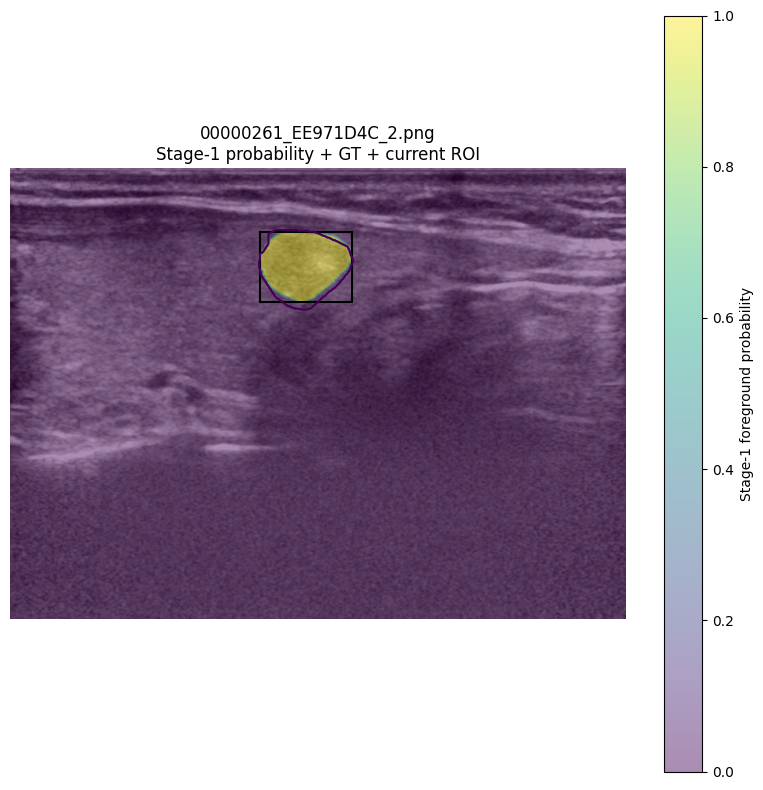

In [8]:
# ============================================================================
# Main dataset loop — Phase 1 probability analysis, Stage 1 only
# ============================================================================

def main() -> None:

    """
    Run Stage-1 only and save:
        - binary Stage-1 prediction
        - raw Stage-1 probability arrays
        - probability overlay with GT + Stage-1 bbox
        - probability statistics for missed GT regions
    """

    # ------------------------------------------------------------------------
    # Check paths
    # ------------------------------------------------------------------------

    for required_path in (
        IMG_DIR,
        MASK_DIR,
        WEIGHT_C1,
    ):
        if not required_path.exists():
            raise FileNotFoundError(
                f"Path not found: {required_path}"
            )

    # ------------------------------------------------------------------------
    # Output directories
    # ------------------------------------------------------------------------

    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    PREDICTION_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    PROBABILITY_NUMPY_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    PROBABILITY_OVERLAY_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    if SAVE_OVERLAYS:
        OVERLAY_DIR.mkdir(
            parents=True,
            exist_ok=True,
        )

    # ------------------------------------------------------------------------
    # CSV fields
    # ------------------------------------------------------------------------

    fieldnames = [

        "image_name",

        "prediction_path",
        "probability_array_path",
        "probability_overlay_path",

        "stage1_bbox",

        "iou",
        "dsc",
        "recall",

        "missed_gt_pixels",
        "missed_gt_mean_probability",
        "missed_gt_median_probability",
        "missed_gt_max_probability",

        "missed_gt_fraction_above_0_1",
        "missed_gt_fraction_above_0_2",
        "missed_gt_fraction_above_0_3",
        "missed_gt_fraction_above_0_4",

        "gt_outside_bbox_pixels",
        "gt_outside_bbox_mean_probability",
        "gt_outside_bbox_max_probability",
        "fraction_gt_outside_bbox",

        "status",
        "error",
    ]

    # ------------------------------------------------------------------------
    # Device + data
    # ------------------------------------------------------------------------

    device = choose_device()

    image_files = discover_images(
        IMG_DIR
    )

    mask_index = build_mask_index(
        MASK_DIR
    )

    if not image_files:
        raise RuntimeError(
            f"No supported images found in {IMG_DIR}"
        )

    if MAX_IMAGES is not None:
        image_files = image_files[:MAX_IMAGES]

    # ------------------------------------------------------------------------
    # Check masks
    # ------------------------------------------------------------------------

    missing_masks = [
        image_path.name

        for image_path in image_files

        if image_path.stem.lower()
        not in mask_index
    ]

    if missing_masks:
        raise FileNotFoundError(
            f"{len(missing_masks)} images "
            f"do not have matching masks."
        )

    # ------------------------------------------------------------------------
    # TTA
    # ------------------------------------------------------------------------

    tta_transforms = tta.Compose(
        [
            tta.VerticalFlip(),
            tta.HorizontalFlip(),
            tta.Rotate90(
                angles=[0, 180]
            ),
        ]
    )

    # ------------------------------------------------------------------------
    # Load Stage-1 model
    # ------------------------------------------------------------------------

    print(
        f"Loading Stage-1 model on {device}..."
    )

    model_cascade1 = load_model(
        WEIGHT_C1,
        device,
        tta_transforms,
        C1_TTA,
    )

    print(
        f"Processing {len(image_files)} images."
    )

    # ------------------------------------------------------------------------
    # Run inference
    # ------------------------------------------------------------------------

    results: List[Dict] = []

    failed_count = 0

    for index, image_path in enumerate(
        image_files,
        start=1,
    ):

        mask_path = mask_index[
            image_path.stem.lower()
        ]

        try:

            # ------------------------------------------------------------
            # Load GT
            # ------------------------------------------------------------

            with Image.open(image_path) as original_image:
                original_shape = (
                    original_image.height,
                    original_image.width,
                )

            ground_truth = load_binary_mask(
                mask_path,
                original_shape,
            )

            # ------------------------------------------------------------
            # Stage-1 inference
            # ------------------------------------------------------------

            (
                stage1_probability_original,
                stage1_probability_256,
                stage1_binary_raw_256,
                stage1_mask_256,
                stage1_mask_original,
                stage1_bbox,
            ) = run_stage1_only(
                image_path,
                model_cascade1,
                device,
            )

            # ------------------------------------------------------------
            # Metrics
            # ------------------------------------------------------------

            iou = get_iou(
                stage1_mask_original,
                ground_truth,
            )

            dsc = get_dsc(
                stage1_mask_original,
                ground_truth,
            )

            recall = get_recall(
                stage1_mask_original,
                ground_truth,
            )

            probability_stats = (
                analyze_missed_gt_probabilities(
                    stage1_probability_original,
                    stage1_mask_original,
                    ground_truth,
                    stage1_bbox,
                )
            )

            # ------------------------------------------------------------
            # Save binary mask
            # ------------------------------------------------------------

            prediction_path = (
                PREDICTION_DIR
                / f"{image_path.stem}_stage1.png"
            )

            save_binary_mask(
                stage1_mask_original,
                prediction_path,
            )

            # ------------------------------------------------------------
            # Save probability array
            # ------------------------------------------------------------

            probability_array_path = (
                PROBABILITY_NUMPY_DIR
                / (
                    f"{image_path.stem}"
                    f"_stage1_probability.npy"
                )
            )

            np.save(
                probability_array_path,
                stage1_probability_original.astype(
                    np.float32
                ),
            )

            # ------------------------------------------------------------
            # Save probability overlay
            # ------------------------------------------------------------

            probability_overlay_path = (
                PROBABILITY_OVERLAY_DIR
                / (
                    f"{image_path.stem}"
                    f"_stage1_probability_overlay.png"
                )
            )

            save_probability_overlay(
                image_path=image_path,
                probability_map=stage1_probability_original,
                ground_truth=ground_truth,
                output_path=probability_overlay_path,
                bbox=stage1_bbox,
            )

            # ------------------------------------------------------------
            # Optional standard binary overlay
            # ------------------------------------------------------------

            if SAVE_OVERLAYS:

                overlay_path = (
                    OVERLAY_DIR
                    / (
                        f"{image_path.stem}"
                        f"_stage1_overlay.png"
                    )
                )

                save_overlay(
                    image_path,
                    stage1_mask_original,
                    ground_truth,
                    overlay_path,
                    prediction_bbox=stage1_bbox,
                )

            # ------------------------------------------------------------
            # Bbox text
            # ------------------------------------------------------------

            bbox_text = ""

            if stage1_bbox is not None:

                (
                    row_min,
                    col_min,
                    row_max,
                    col_max,
                ) = stage1_bbox

                bbox_text = (
                    f"{row_min},"
                    f"{col_min},"
                    f"{row_max},"
                    f"{col_max}"
                )

            # ------------------------------------------------------------
            # Save row
            # ------------------------------------------------------------

            result = {

                "image_name":
                    image_path.name,

                "prediction_path":
                    str(prediction_path),

                "probability_array_path":
                    str(probability_array_path),

                "probability_overlay_path":
                    str(probability_overlay_path),

                "stage1_bbox":
                    bbox_text,

                "iou":
                    iou,

                "dsc":
                    dsc,

                "recall":
                    recall,

                "missed_gt_pixels":
                    probability_stats[
                        "missed_gt_pixels"
                    ],

                "missed_gt_mean_probability":
                    probability_stats[
                        "missed_gt_mean_probability"
                    ],

                "missed_gt_median_probability":
                    probability_stats[
                        "missed_gt_median_probability"
                    ],

                "missed_gt_max_probability":
                    probability_stats[
                        "missed_gt_max_probability"
                    ],

                "missed_gt_fraction_above_0_1":
                    probability_stats[
                        "missed_gt_fraction_above_0_1"
                    ],

                "missed_gt_fraction_above_0_2":
                    probability_stats[
                        "missed_gt_fraction_above_0_2"
                    ],

                "missed_gt_fraction_above_0_3":
                    probability_stats[
                        "missed_gt_fraction_above_0_3"
                    ],

                "missed_gt_fraction_above_0_4":
                    probability_stats[
                        "missed_gt_fraction_above_0_4"
                    ],

                "gt_outside_bbox_pixels":
                    probability_stats[
                        "gt_outside_bbox_pixels"
                    ],

                "gt_outside_bbox_mean_probability":
                    probability_stats[
                        "gt_outside_bbox_mean_probability"
                    ],

                "gt_outside_bbox_max_probability":
                    probability_stats[
                        "gt_outside_bbox_max_probability"
                    ],

                "fraction_gt_outside_bbox":
                    probability_stats[
                        "fraction_gt_outside_bbox"
                    ],

                "status":
                    "ok",

                "error":
                    "",
            }

            results.append(
                result
            )

            # ------------------------------------------------------------
            # Minimal useful console output
            # ------------------------------------------------------------

            print(
                f"[{index}/{len(image_files)}] "
                f"{image_path.name} "
                f"| Recall={recall:.3f} "
                f"| Missed GT mean p="
                f"{probability_stats['missed_gt_mean_probability']:.3f} "
                f"| Outside bbox="
                f"{probability_stats['fraction_gt_outside_bbox']:.3f}"
            )

        except Exception as exc:

            failed_count += 1

            print(
                f"[{index}/{len(image_files)}] "
                f"FAILED: {image_path.name} "
                f"| {exc}"
            )

            failed_result = {
                field: ""
                for field in fieldnames
            }

            failed_result.update(
                {
                    "image_name":
                        image_path.name,

                    "status":
                        "failed",

                    "error":
                        str(exc),
                }
            )

            results.append(
                failed_result
            )

            if not CONTINUE_ON_ERROR:
                break

    # ------------------------------------------------------------------------
    # Save CSV
    # ------------------------------------------------------------------------

    with METRICS_CSV.open(
        "w",
        newline="",
        encoding="utf-8",
    ) as csv_file:

        writer = csv.DictWriter(
            csv_file,
            fieldnames=fieldnames,
        )

        writer.writeheader()
        writer.writerows(results)

    # ------------------------------------------------------------------------
    # Minimal final summary
    # ------------------------------------------------------------------------

    successful_count = sum(
        row["status"] == "ok"
        for row in results
    )

    print(
        "\nDone."
    )

    print(
        f"Successful: {successful_count}"
    )

    print(
        f"Failed: {failed_count}"
    )

    print(
        f"Probability overlays: "
        f"{PROBABILITY_OVERLAY_DIR}"
    )

    print(
        f"Metrics CSV: "
        f"{METRICS_CSV}"
    )


main()

# Observations

1. mean recall for images = 0.73
    - large portion of TP are not accounted for 
    - poor coverage by first localization before expansion to margin (recall at this stage has not been observed)

2. 